Heart Disease Dataset Analysis

This project explores patient demographics, heart disease distribution, and data quality issues in the Heart Disease dataset. The goal is to understand who is represented in the dataset, identify suspicious or missing values, and prepare the data for reliable analysis.

In [1]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

In [2]:
#Load Data Function
def load_data(file_path):
    """
    Loads a CSV file and returns a DataFrame.
    Handles missing files and empty CSV files.
    """
    try:
        df = pd.read_csv(file_path)
        print(f"Data loaded successfully. DataFrame shape: {df.shape}")
        return df
    
    except FileNotFoundError:
        print(f"File not found at: {file_path}")
    
    except pd.errors.EmptyDataError:
        print("The CSV file is empty.")

In [3]:
#Test Error Handling
load_data("wrong.csv")

File not found at: wrong.csv


In [4]:
#Load Actual Dataset
df = load_data("../data/heart.csv")
df.head()

Data loaded successfully. DataFrame shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 1. Data Overview

This section reviews the dataset shape, first few rows, column types, summary statistics, and category distributions.

In [5]:
#Basic Preview
df.head(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [6]:
#Data Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [7]:
#Summary Statistics
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [8]:
#Category Value Counts
categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())


Value counts for Sex:
Sex
M    725
F    193
Name: count, dtype: int64

Value counts for ChestPainType:
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

Value counts for RestingECG:
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

Value counts for ExerciseAngina:
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

Value counts for ST_Slope:
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


- **Age**: patient age in years.
- **Sex**: patient sex, recorded as M for male and F for female.
- **ChestPainType**: type of chest pain experienced by the patient.
- **RestingBP**: resting blood pressure measured in mm Hg.
- **Cholesterol**: serum cholesterol measured in mg/dL.
- **FastingBS**: fasting blood sugar indicator, where 1 means fasting blood sugar is greater than 120 mg/dL and 0 means otherwise.
- **RestingECG**: resting electrocardiogram result.
- **MaxHR**: maximum heart rate achieved during testing.
- **ExerciseAngina**: exercise-induced angina, recorded as Y for yes and N for no.
- **Oldpeak**: ST depression induced by exercise relative to rest.
- **ST_Slope**: slope of the peak exercise ST segment.
- **HeartDisease**: target variable, where 1 indicates heart disease and 0 indicates no heart disease.

The numeric columns are Age, RestingBP, Cholesterol, FastingBS, MaxHR, Oldpeak, and HeartDisease; the categorical object columns are Sex, ChestPainType, RestingECG, ExerciseAngina, and ST_Slope.

## 2. Data Quality Investigation

The minimum values of Cholesterol and RestingBP are 0, which is biologically impossible for living patients. This suggests these zeros are not real measurements but disguised missing values recorded as 0 instead of being left blank.

In [9]:
#Check Impossible Zero Values
zero_cholesterol = df["Cholesterol"] == 0
zero_restingbp = df["RestingBP"] == 0

print(f"Patients with zero Cholesterol: {zero_cholesterol.sum()}")
print(f"Patients with zero RestingBP: {zero_restingbp.sum()}")

print(f"Percentage with zero Cholesterol: {zero_cholesterol.mean():.1%}")
print(f"Percentage with zero RestingBP: {zero_restingbp.mean():.1%}")

Patients with zero Cholesterol: 172
Patients with zero RestingBP: 1
Percentage with zero Cholesterol: 18.7%
Percentage with zero RestingBP: 0.1%


In [10]:
#Compare Disease Rates
heart_disease = df["HeartDisease"] == 1

overall_disease_rate = heart_disease.mean()
zero_chol_disease_rate = df.loc[zero_cholesterol, "HeartDisease"].mean()

print(f"Overall HeartDisease rate: {overall_disease_rate:.1%}")
print(f"Total patients with HeartDisease: {heart_disease.sum()}")
print(f"Disease rate among zero-cholesterol patients: {zero_chol_disease_rate:.1%}")

Overall HeartDisease rate: 55.3%
Total patients with HeartDisease: 508
Disease rate among zero-cholesterol patients: 88.4%


Dropping zero-cholesterol records is unsafe because this group is 88.4% diseased. Removing these rows would eliminate nearly 30% of all diseased cases and bias the dataset toward healthier patients.

In [11]:
#Clean Data


df["Cholesterol"] = df["Cholesterol"].replace(0, np.nan)
df["RestingBP"] = df["RestingBP"].replace(0, np.nan)

df = df.dropna(subset=["RestingBP"])

median_cholesterol = df["Cholesterol"].median()
df["Cholesterol"] = df["Cholesterol"].fillna(median_cholesterol)

print(f"Cleaned DataFrame shape: {df.shape}")
print(f"Median Cholesterol used for imputation: {median_cholesterol}")

Cleaned DataFrame shape: (917, 12)
Median Cholesterol used for imputation: 237.0


In [12]:
#Validate Cleaning
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000
mean,53.509269,132.540894,243.211559,0.233370,136.789531,0.886696,0.552890
std,9.437636,17.999749,53.430044,0.423206,25.467129,1.066960,0.497466
min,28.000000,80.000000,85.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,214.000000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,237.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [13]:
#Check Duplicates
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


## 3. Q1 — Who is in this dataset?

This section examines patient age, sex distribution, and heart disease balance to understand the population represented in the dataset.

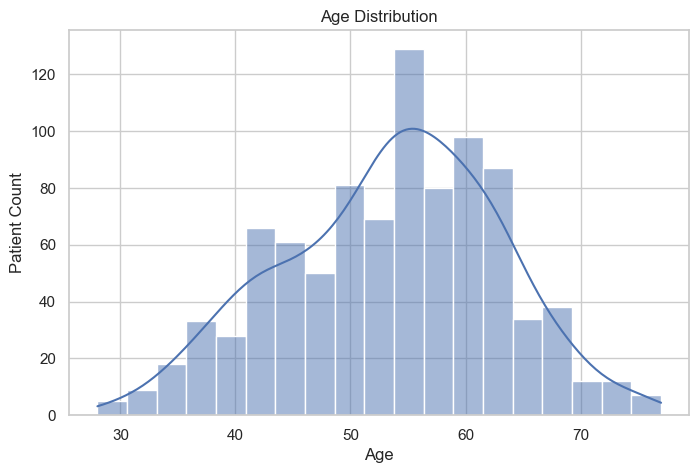

In [14]:
#Age Distribution Chart
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Patient Count")
plt.savefig("../images/01_age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
# Age Summary
df["Age"].describe()

count    917.000000
mean      53.509269
std        9.437636
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: Age, dtype: float64

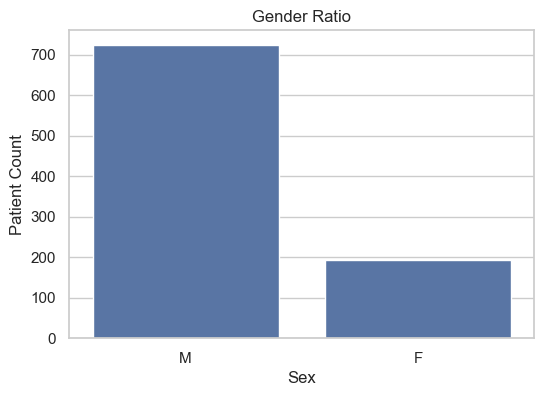

In [16]:
#Gender Ratio Chart
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Sex")
plt.title("Gender Ratio")
plt.xlabel("Sex")
plt.ylabel("Patient Count")
plt.savefig("../images/02_gender_ratio.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
#Gender Counts and Percentages
sex_counts = df["Sex"].value_counts()
sex_percentages = df["Sex"].value_counts(normalize=True) * 100

gender_summary = pd.DataFrame({
    "Count": sex_counts,
    "Percentage": sex_percentages.round(1)
})

gender_summary

,Count,Percentage
Sex,,
M,724,79.0
F,193,21.0


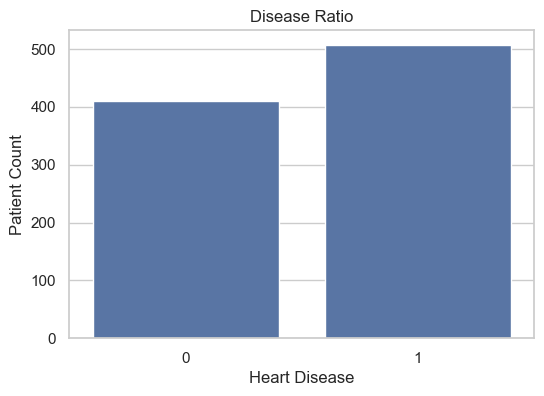

In [18]:
#Disease Ratio Chart
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="HeartDisease")
plt.title("Disease Ratio")
plt.xlabel("Heart Disease")
plt.ylabel("Patient Count")
plt.savefig("../images/03_disease_ratio.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
#Disease Counts and Percentages
disease_counts = df["HeartDisease"].value_counts()
disease_percentages = df["HeartDisease"].value_counts(normalize=True) * 100

disease_summary = pd.DataFrame({
    "Count": disease_counts,
    "Percentage": disease_percentages.round(1)
})

disease_summary

,Count,Percentage
HeartDisease,,
1,507,55.3
0,410,44.7


The dataset includes adult patients from ages 28 to 77, with most patients falling between 47 and 60 years old and a median age of 54.

Male patients make up 724 of 917 records, or 79.0%, while female patients make up 193 records, or 21.0%.

Heart disease is present in 507 of 917 patients, or 55.3%, while 410 patients are healthy, making the target variable fairly balanced.

A key limitation is that about 79% of the dataset is male, so findings from this dataset may not generalize well to female patients.

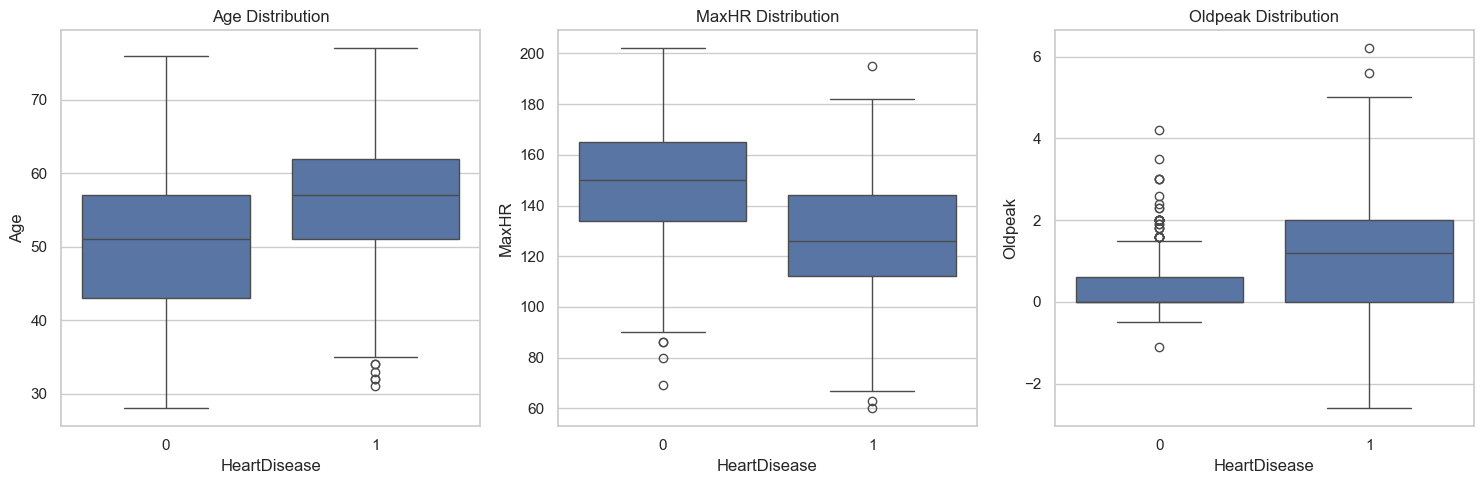

In [20]:

fig,axes=plt.subplots(1,3,figsize=(15,5))



sns.boxplot(df,y='Age',x='HeartDisease',ax=axes[0])
axes[0].set_title("Age Distribution")
axes[0].set_ylabel("Age")
axes[0].set_xlabel("HeartDisease")
sns.boxplot(df,y='MaxHR',x='HeartDisease',ax=axes[1])
axes[1].set_title("MaxHR Distribution")
axes[1].set_ylabel("MaxHR")
axes[1].set_xlabel("HeartDisease")
sns.boxplot(df,y='Oldpeak',x='HeartDisease',ax=axes[2])
axes[2].set_title("Oldpeak Distribution")
axes[2].set_ylabel("Oldpeak")
axes[2].set_xlabel("HeartDisease")
plt.tight_layout()
fig.savefig("../images/04_numeric_boxplots.png", dpi=300, bbox_inches="tight")
plt.show()

### Q1 Verdict: Age, MaxHR, and Oldpeak by Heart Disease Status

The diseased group (`HeartDisease = 1`) skews older than the healthy group (`HeartDisease = 0`), with a higher median age and most diseased patients concentrated in older age ranges.

The diseased group has a lower maximum heart rate (`MaxHR`) compared with the healthy group, suggesting patients with heart disease generally achieved lower peak heart rates during testing.

The diseased group shows higher `Oldpeak` values, meaning they had greater ST depression during exercise, which is more strongly associated with heart disease.

Overall, older age, lower maximum heart rate, and higher ST depression appear to be important patterns separating diseased and healthy patients in this dataset.

In [21]:
cols=['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
k=df.groupby('HeartDisease')[cols].mean()
print(k)


                    Age   RestingBP  Cholesterol       MaxHR   Oldpeak
HeartDisease                                                          
0             50.551220  130.180488   238.682927  148.151220  0.408049
1             55.901381  134.449704   246.873767  127.601578  1.273767


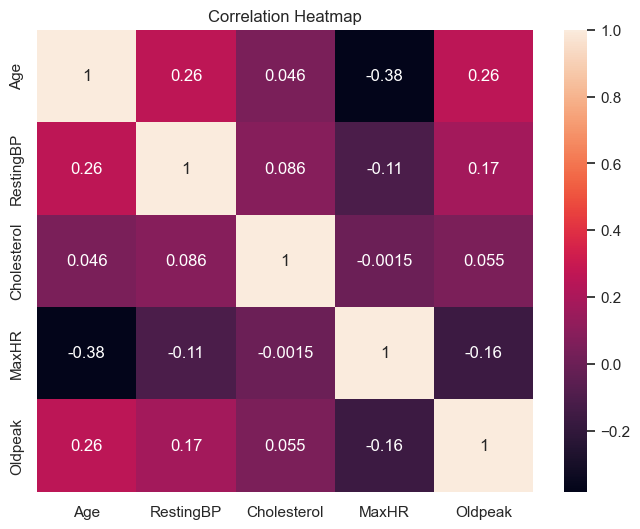

In [22]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[cols].corr(), annot=True)
plt.title("Correlation Heatmap")

plt.savefig("../images/05_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### Q2 Verdict: Top Numeric Signals
The clearest numeric signals separating sick and healthy patients are **MaxHR**, **Oldpeak**, and **Age**. Diseased patients have much lower maximum heart rate on average, **127.6 vs. 148.2**, a difference of about **20.5 bpm**, making **MaxHR** the strongest separator.
**Oldpeak** is the second strongest signal because diseased patients show higher ST depression, **1.27 vs. 0.41**, a difference of about **0.87**. **Age** ranks third because diseased patients are older on average, **55.9 vs. 50.6 years**, while the heatmap also shows MaxHR moving negatively against Age and Oldpeak.

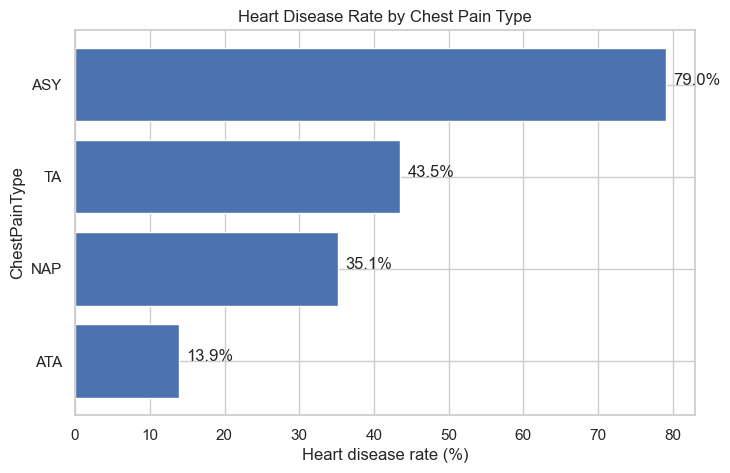

,ChestPainType,disease_rate
1,ATA,13.872832
2,NAP,35.148515
3,TA,43.478261
0,ASY,79.032258


In [23]:
chestpain_rate = (
    df.groupby("ChestPainType")["HeartDisease"]
    .mean()
    .mul(100)
    .reset_index(name="disease_rate")
    .sort_values("disease_rate")
)

plt.figure(figsize=(8, 5))
plt.barh(chestpain_rate["ChestPainType"], chestpain_rate["disease_rate"])
plt.xlabel("Heart disease rate (%)")
plt.ylabel("ChestPainType")
plt.title("Heart Disease Rate by Chest Pain Type")

for index, value in enumerate(chestpain_rate["disease_rate"]):
    plt.text(value + 1, index, f"{value:.1f}%")
plt.savefig("../images/06_chestpain_disease_rate.png", dpi=300, bbox_inches="tight")

plt.show()

chestpain_rate

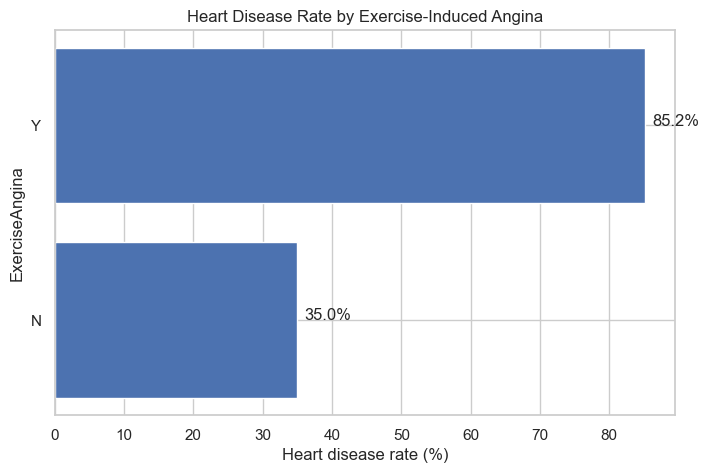

,ExerciseAngina,disease_rate
0,N,34.981685
1,Y,85.175202


In [24]:
angina_rate = (
    df.groupby("ExerciseAngina")["HeartDisease"]
    .mean()
    .mul(100)
    .reset_index(name="disease_rate")
    .sort_values("disease_rate")
)

plt.figure(figsize=(8, 5))
plt.barh(angina_rate["ExerciseAngina"], angina_rate["disease_rate"])
plt.xlabel("Heart disease rate (%)")
plt.ylabel("ExerciseAngina")
plt.title("Heart Disease Rate by Exercise-Induced Angina")

for index, value in enumerate(angina_rate["disease_rate"]):
    plt.text(value + 1, index, f"{value:.1f}%")
    
plt.savefig("../images/07_exercise_angina_disease_rate.png", dpi=300, bbox_inches="tight")

plt.show()

angina_rate

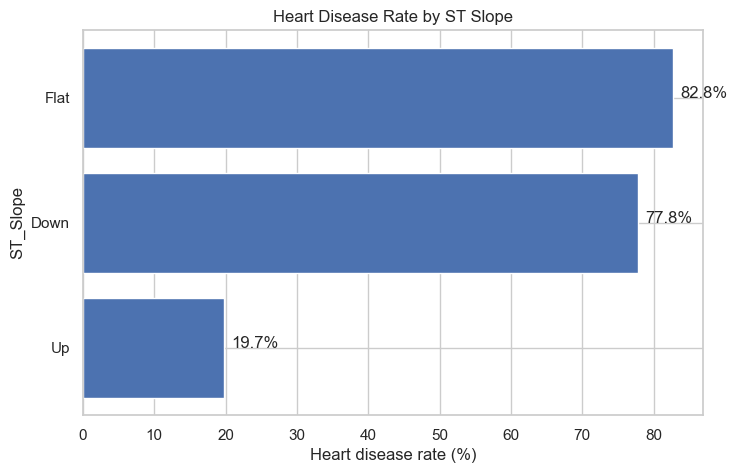

,ST_Slope,disease_rate
2,Up,19.746835
0,Down,77.777778
1,Flat,82.788671


In [25]:
st_slope_rate = (
    df.groupby("ST_Slope")["HeartDisease"]
    .mean()
    .mul(100)
    .reset_index(name="disease_rate")
    .sort_values("disease_rate")
)

plt.figure(figsize=(8, 5))
plt.barh(st_slope_rate["ST_Slope"], st_slope_rate["disease_rate"])
plt.xlabel("Heart disease rate (%)")
plt.ylabel("ST_Slope")
plt.title("Heart Disease Rate by ST Slope")

for index, value in enumerate(st_slope_rate["disease_rate"]):
    plt.text(value + 1, index, f"{value:.1f}%")
    
plt.savefig("../images/08_st_slope_disease_rate.png", dpi=300, bbox_inches="tight")
plt.show()

st_slope_rate

### E-Q3 Verdict: Categorical Disease Rate Signals

The single most dramatic category is **ExerciseAngina = Y**, where about **85%** of patients have heart disease, making it the strongest categorical warning signal among these charts.

The most surprising finding is **ASY chest pain**, because “asymptomatic” sounds less severe, but it still has a very high disease rate of about **79%**.

This suggests that many high-risk patients may not report typical chest pain symptoms, so ASY chest pain is important for identifying hidden heart disease risk.

## 7. Q4 — Probability & Bayes Theorem Applied

In [26]:
# Prior probability: P(Disease)
prior_disease = df["HeartDisease"].mean()

# Disease probability given ExerciseAngina = Y
exercise_y = df["ExerciseAngina"] == "Y"
p_disease_given_y = df.loc[exercise_y, "HeartDisease"].mean()

# Disease probability given ExerciseAngina = N
exercise_n = df["ExerciseAngina"] == "N"
p_disease_given_n = df.loc[exercise_n, "HeartDisease"].mean()

# Disease probability given ChestPainType = ASY
asy = df["ChestPainType"] == "ASY"
p_disease_given_asy = df.loc[asy, "HeartDisease"].mean()

print(f"P(Disease): {prior_disease:.1%}")
print(f"P(Disease | ExerciseAngina = Y): {p_disease_given_y:.1%}")
print(f"P(Disease | ExerciseAngina = N): {p_disease_given_n:.1%}")
print(f"P(Disease | ChestPainType = ASY): {p_disease_given_asy:.1%}")

P(Disease): 55.3%
P(Disease | ExerciseAngina = Y): 85.2%
P(Disease | ExerciseAngina = N): 35.0%
P(Disease | ChestPainType = ASY): 79.0%


In [27]:
#using numpy
exercise = df["ExerciseAngina"].values
disease = df["HeartDisease"].values

exercise_y_numeric = np.where(exercise == "Y", 1, 0)

# P(Y | Disease)
p_y_given_disease = exercise_y_numeric[disease == 1].mean()

# P(Disease)
p_disease = disease.mean()

# P(Y)
p_y = exercise_y_numeric.mean()

# Bayes theorem: P(Disease | Y) = P(Y | Disease) * P(Disease) / P(Y)
bayes_result = (p_y_given_disease * p_disease) / p_y

print(f"P(Y | Disease): {p_y_given_disease:.1%}")
print(f"P(Disease): {p_disease:.1%}")
print(f"P(Y): {p_y:.1%}")
print(f"Bayes result P(Disease | ExerciseAngina = Y): {bayes_result:.1%}")


'''
Using PANDAS
filt = df["HeartDisease"] == 1

a = df.copy()
a["ExerciseAngina"] = df["ExerciseAngina"].apply(lambda x: 1 if x == "Y" else 0)

# P(Y | Disease)
c1 = a.loc[filt, "ExerciseAngina"].mean()

# P(Disease)
c2 = a["HeartDisease"].mean()

# P(Y)
c3 = a["ExerciseAngina"].mean()

bayes_result = (c1 * c2) / c3
print(f"Bayes result P(Disease | ExerciseAngina = Y): {bayes_result:.1%}")
'''

P(Y | Disease): 62.3%
P(Disease): 55.3%
P(Y): 40.5%
Bayes result P(Disease | ExerciseAngina = Y): 85.2%


'\nUsing PANDAS\nfilt = df["HeartDisease"] == 1\n\na = df.copy()\na["ExerciseAngina"] = df["ExerciseAngina"].apply(lambda x: 1 if x == "Y" else 0)\n\n# P(Y | Disease)\nc1 = a.loc[filt, "ExerciseAngina"].mean()\n\n# P(Disease)\nc2 = a["HeartDisease"].mean()\n\n# P(Y)\nc3 = a["ExerciseAngina"].mean()\n\nbayes_result = (c1 * c2) / c3\nprint(f"Bayes result P(Disease | ExerciseAngina = Y): {bayes_result:.1%}")\n'

```markdown
### E-Q4 Verdict: Probability and Bayes Theorem

The prior probability of heart disease in the dataset is about **55.3%**, meaning a patient has a little over a one-in-two chance of heart disease before using any symptom information.

Exercise-induced angina changes that risk sharply: patients with **ExerciseAngina = Y** have about an **85%** disease rate, while patients with **ExerciseAngina = N** have about a **35%** disease rate.

The Bayes verification proves that calculating **P(Disease | ExerciseAngina = Y)** directly from the data matches the Bayes theorem result, confirming that exercise angina is strongly linked with heart disease risk.

A practical implication for a doctor is that a patient reporting exercise-induced angina should be treated as much higher risk and may need faster follow-up testing or closer clinical evaluation.
```


## 8. Q5 — Age Group + ST Slope Risk

This section checks whether `ST_Slope` continues to separate heart disease risk after patients are split into age groups. I use two approaches: a manual subplot method for practice, and a cleaner `catplot()` method that avoids hard coding.

In [28]:
new = df.copy()
# def Category_Age(age):
#     if age<50:
#         return 'under 50'
#     elif age>=50 and age<60:
#         return '50 - 60'
#     else:
#         return 'over 60'
# df['Age_group']=df['Age'].apply(Category_Age)


new["Age_group"] = pd.cut(
    new["Age"],
    bins=[0, 50, 60, 100],
    labels=["under 50", "50 - 60", "over 60"]
)

age_slope_rate = (
    new.groupby(["Age_group", "ST_Slope"], observed=True)["HeartDisease"]
    .mean()
    .mul(100)
    .reset_index(name="disease_rate")
)

age_slope_rate

,Age_group,ST_Slope,disease_rate
0,under 50,Down,70.000000
1,under 50,Flat,77.777778
2,under 50,Up,11.111111
3,50 - 60,Down,72.000000
4,50 - 60,Flat,83.919598
5,50 - 60,Up,23.076923
6,over 60,Down,85.714286
7,over 60,Flat,85.820896
8,over 60,Up,37.288136


### Method 1 — Manual Subplots

This method manually filters each age group and plots each group separately. It works, but it is more hard coded because every age group needs its own filter and subplot.

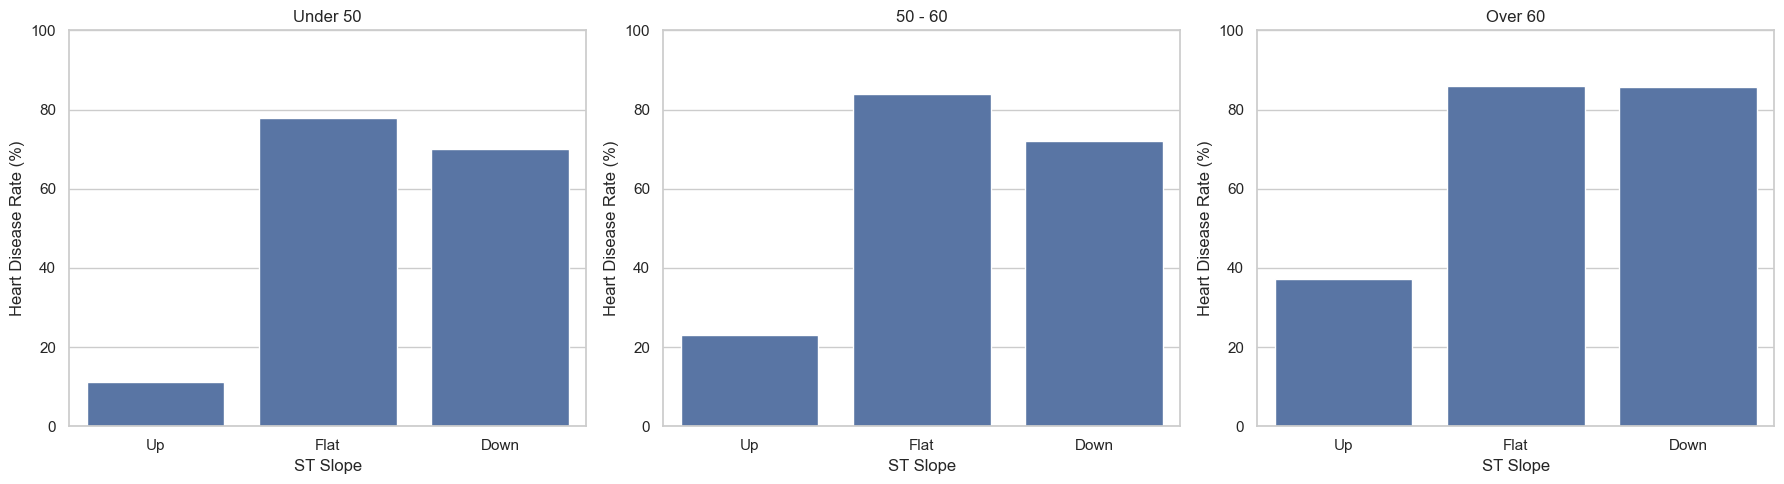

In [29]:
filt1 = age_slope_rate["Age_group"] == "under 50"
i = age_slope_rate.loc[filt1, ["ST_Slope", "disease_rate"]]

filt2 = age_slope_rate["Age_group"] == "50 - 60"
j = age_slope_rate.loc[filt2, ["ST_Slope", "disease_rate"]]

filt3 = age_slope_rate["Age_group"] == "over 60"
k = age_slope_rate.loc[filt3, ["ST_Slope", "disease_rate"]]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=i, x="ST_Slope", y="disease_rate", errorbar=None, ax=axes[0], order=["Up", "Flat", "Down"])
sns.barplot(data=j, x="ST_Slope", y="disease_rate", errorbar=None, ax=axes[1], order=["Up", "Flat", "Down"])
sns.barplot(data=k, x="ST_Slope", y="disease_rate", errorbar=None, ax=axes[2], order=["Up", "Flat", "Down"])

axes[0].set_title("Under 50")
axes[1].set_title("50 - 60")
axes[2].set_title("Over 60")

for ax in axes:
    ax.set_xlabel("ST Slope")
    ax.set_ylabel("Heart Disease Rate (%)")
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

### Method 2 — Cleaner Catplot Method

This method is cleaner because `catplot()` automatically creates one bar chart for each age group. It avoids manually creating separate DataFrames like `i`, `j`, and `k`.

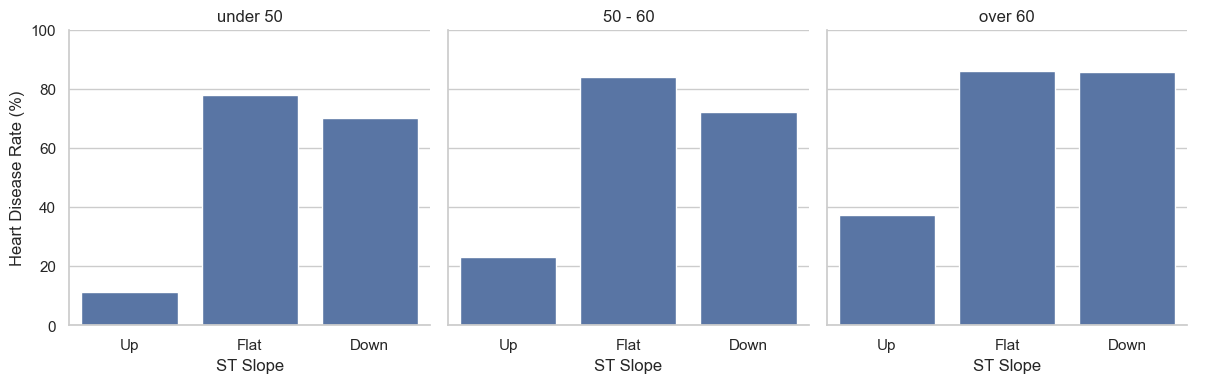

In [30]:
g = sns.catplot(
    data=age_slope_rate,
    x="ST_Slope",
    y="disease_rate",
    col="Age_group",
    kind="bar",
    errorbar=None,
    height=4,
    aspect=1,
    order=["Up", "Flat", "Down"]
)

g.set_axis_labels("ST Slope", "Heart Disease Rate (%)")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.set_ylim(0, 100)
g.savefig("../images/09_age_group_st_slope.png", dpi=300, bbox_inches="tight")

plt.show()

In [31]:
highest_risk = age_slope_rate.sort_values("disease_rate", ascending=False).head(1)

highest_risk

,Age_group,ST_Slope,disease_rate
7,over 60,Flat,85.820896


### E-Q5 Verdict: Age Group and ST Slope Risk

Across all age groups, **ST_Slope = Up** has the lowest heart disease rate, while **Flat** and **Down** consistently show much higher disease rates.

The highest-risk combination is **over 60 with ST_Slope = Down**, with a heart disease rate of about **86%**.

Clinically, this means older patients with abnormal ST slope patterns, especially **Down** or **Flat**, should be treated as higher-risk and may need closer cardiac evaluation.

```markdown
## 9. Reusable DataExplorer Class

This section uses a custom `DataExplorer` class from the `src` folder to make the analysis more modular and reusable. Instead of rewriting the same pandas code repeatedly, the class stores common exploration methods such as missing-value checks, disease-rate calculations, and conditional probability.
```


In [32]:
import sys
sys.path.append('..')
from src.explorer import DataExplorer
explorer = DataExplorer('../data/heart.csv')

In [33]:
explorer.shape()
explorer.null_report()
explorer.zero_report()
explorer.disease_rate_by("ChestPainType")
explorer.cond_prob("ExerciseAngina", "Y")
explorer.bayes_verify("ExerciseAngina", "Y")
explorer.add_age_group()
explorer.rate_by_two_groups("Age_group", "ST_Slope")

,Age_group,ST_Slope,disease_rate
6,over 60,Down,86.7
7,over 60,Flat,86.7
4,50 - 60,Flat,83.3
1,under 50,Flat,76.8
0,under 50,Down,70.0
3,50 - 60,Down,69.6
8,over 60,Up,39.7
5,50 - 60,Up,20.3
2,under 50,Up,10.7


```markdown
### DataExplorer Results Summary

The `shape()` method confirms the dataset size, helping verify that the file loaded correctly before analysis.

The `null_report()` method checks for actual missing values in each column, while `zero_report()` checks suspicious zero values in `Cholesterol` and `RestingBP` that may represent disguised missing data.

The `disease_rate_by("ChestPainType")` method calculates heart disease rate for each chest pain category, helping identify which symptom group carries the highest risk.

The `cond_prob("ExerciseAngina", "Y")` method calculates the probability of heart disease when exercise-induced angina is present, supporting the conditional probability analysis.

The `bayes_verify("ExerciseAngina", "Y")` method confirms that the Bayes theorem result matches the direct filtering result, proving the probability calculation is consistent.

The `add_age_group()` method creates age groups for comparing younger, middle-aged, and older patients.

The `rate_by_two_groups("Age_group", "ST_Slope")` method compares disease rates across both age group and ST slope, showing how abnormal ST slope patterns remain important across age groups.
```


```markdown
### Reusability Verdict

Using the `DataExplorer` class makes the project cleaner because repeated analysis logic is moved into reusable functions. This improves notebook structure, reduces duplicate code, and makes the analysis easier to read, test, and extend.
```

```markdown
## Key Insights

1. The dataset contains **917 patients**, with heart disease present in **507 patients (55.3%)** and absent in **410 patients (44.7%)**, making the target variable fairly balanced.

2. The dataset is strongly male-heavy, with **724 male patients (79.0%)** and **193 female patients (21.0%)**, so findings may not generalize equally to female patients.

3. The strongest numeric separators are **MaxHR**, **Oldpeak**, and **Age**: diseased patients average about **20.5 bpm lower MaxHR**, **0.86 higher Oldpeak**, and **5.3 years older** than healthy patients.

4. Categorical symptoms show strong risk differences, especially **ExerciseAngina = Y**, where about **85%** of patients have heart disease compared with about **35%** for ExerciseAngina = N.

5. The dirty-data investigation found that **zero Cholesterol values were not safe to drop** because that group had about an **88.4% disease rate**, so median imputation was safer than deleting those records.
```